导入处理后的训练数据

In [7]:
import os

# 先设置 OpenMP 相关环境变量（必须在导入 numpy/torch/torchvision 之前）
os.environ["KMP_DUPLICATE_LIB_OK"] = "TRUE"  # 临时绕过 libomp/libiomp 冲突
os.environ["OMP_NUM_THREADS"] = "1"

import torchvision
import torchvision.transforms as transforms
import numpy as np

def binarize(x):
    return (x > 0.5).float()

transform = transforms.Compose([
    transforms.Resize((10, 10)),
    transforms.ToTensor(),
    transforms.Lambda(binarize)
])

dataset = torchvision.datasets.MNIST(
    root='./data',
    train=True,
    download=True,
    transform=transform
)

In [8]:
X = []
y = []

for img, label in dataset:
    X.append(img.numpy())   # (1,10,10)
    y.append(label)

X = np.array(X)  # (N,1,10,10) #第二个维度是通道数，MNIST是单通道图像，所以是1
y = np.array(y)

print("X shape:", X.shape)
print("y shape:", y.shape)

X shape: (60000, 1, 10, 10)
y shape: (60000,)


In [ ]:
X1 = []
y1 = []

for img, label in dataset:
    X1.append(img.numpy())   # (1,10,10)
    y1.append(label)
X1 = np.array(X1)  # (N,1,10,10) #第二个维度是通道数，MNIST是单通道图像，所以是1
y1 = np.array(y1)

image=X1[0, 0, :10, :10]

print("X shape:", X1.shape)
print("y shape:", y1.shape)

print("前2个样本的标签:", y1[:2])
print("前2个样本的图像数据（前10个像素）:", X1[:2, 0, :10, :10])

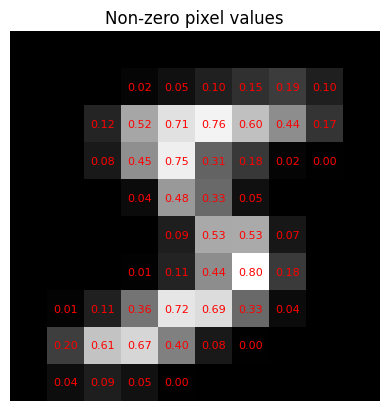

In [15]:
import matplotlib.pyplot as plt

img = X1[0, 0]  # (H, W)

plt.imshow(img, cmap="gray")
plt.axis("off")

H, W = img.shape

for i in range(H):
    for j in range(W):
        val = img[i, j]
        if val > 0:   # 只标非黑像素
            plt.text(j, i, f"{val:.2f}",
                     ha='center', va='center',
                     color='red', fontsize=8)

plt.title("Non-zero pixel values")
plt.show()

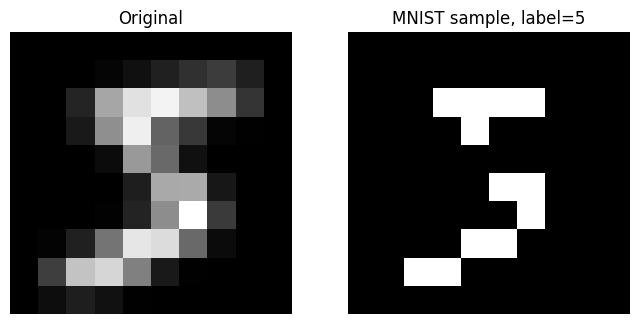

In [14]:
import matplotlib.pyplot as plt

img1 = X1[0, 0]
img2 = X[0, 0]

fig, axes = plt.subplots(1, 2, figsize=(8, 4))
# 左图
axes[0].imshow(img1, cmap="gray")
axes[0].set_title("Original")
axes[0].axis("off")

# 右图
axes[1].imshow(img2, cmap="gray")
axes[1].set_title("Processed")
axes[1].axis("off")

plt.title(f"MNIST sample, label={y[0]}")
plt.show()

In [17]:
import os

save_dir = "./data"
os.makedirs(save_dir, exist_ok=True)

x_path = os.path.join(save_dir, "MNIST_10x10_binarize0.5.npy")
x1_path = os.path.join(save_dir, "MNIST_10x10.npy")
y_path = os.path.join(save_dir, "MNIST_labels.npy")

np.save(x_path, X)
np.save(x1_path, X1)
np.save(y_path, y)

print("Saved:")
print(x_path, X.shape, X.dtype)
print(x1_path, X1.shape, X1.dtype)
print(y_path, y.shape, y.dtype)

Saved:
./data\MNIST_10x10_binarize0.5.npy (60000, 1, 10, 10) float32
./data\MNIST_10x10.npy (60000, 1, 10, 10) float32
./data\MNIST_labels.npy (60000,) int32


储存训练集

In [19]:
import os

# 先设置 OpenMP 相关环境变量（必须在导入 numpy/torch/torchvision 之前）
os.environ["KMP_DUPLICATE_LIB_OK"] = "TRUE"  # 临时绕过 libomp/libiomp 冲突
os.environ["OMP_NUM_THREADS"] = "1"

import torchvision
import torchvision.transforms as transforms
import numpy as np

def binarize(x):
    return (x > 0.5).float()

transform = transforms.Compose([
    transforms.Resize((10, 10)),
    transforms.ToTensor(),
    transforms.Lambda(binarize)
])

dataset = torchvision.datasets.MNIST(
    root='./data',
    train=False,
    download=True,
    transform=transform
)

X2 = []
y2 = []

for img, label in dataset:
    X2.append(img.numpy())   # (1,10,10)
    y2.append(label)
X2 = np.array(X2)  # (N,1,10,10) #第二个维度是通道数，MNIST是单通道图像，所以是1
y2 = np.array(y2)

print("X2 shape:", X2.shape)
print("y2 shape:", y2.shape)

save_dir = "./data"
os.makedirs(save_dir, exist_ok=True)

x2_path = os.path.join(save_dir, "test_MNIST_10x10_binarize0.5.npy")
# x1_path = os.path.join(save_dir, "test_MNIST_10x10.npy")
y2_path = os.path.join(save_dir, "test_MNIST_labels.npy")

np.save(x2_path, X2)
np.save(x1_path, X1)
np.save(y2_path, y2)
print("Saved:")
print(x2_path, X2.shape, X2.dtype)
# print(x1_path, X1.shape, X1.dtype)
print(y2_path, y2.shape, y2.dtype)

X2 shape: (10000, 1, 10, 10)
y2 shape: (10000,)
Saved:
./data\test_MNIST_10x10_binarize0.5.npy (10000, 1, 10, 10) float32
./data\test_MNIST_labels.npy (10000,) int32


对y进行编码

In [25]:
from MNIST.Encode_0to9 import encode_diagonal

print(y[0:100])
print(y.shape)

y_encoded= np.array([encode_diagonal(label) for label in y]).reshape(len(y), -1)
print("y_encoded shape:", y_encoded.shape)
print(y_encoded[0:5])

[5 0 4 1 9 2 1 3 1 4 3 5 3 6 1 7 2 8 6 9 4 0 9 1 1 2 4 3 2 7 3 8 6 9 0 5 6
 0 7 6 1 8 7 9 3 9 8 5 9 3 3 0 7 4 9 8 0 9 4 1 4 4 6 0 4 5 6 1 0 0 1 7 1 6
 3 0 2 1 1 7 9 0 2 6 7 8 3 9 0 4 6 7 4 6 8 0 7 8 3 1]
(60000,)
y_encoded shape: (60000, 100)
[[0 0 0 0 0 1 0 0 0 0 0 0 0 0 0 0 1 0 0 0 0 0 0 0 0 0 0 1 0 0 0 0 0 0 0 0
  0 0 1 0 0 0 0 0 0 0 0 0 0 1 1 0 0 0 0 0 0 0 0 0 0 1 0 0 0 0 0 0 0 0 0 0
  1 0 0 0 0 0 0 0 0 0 0 1 0 0 0 0 0 0 0 0 0 0 1 0 0 0 0 0]
 [1 0 0 0 0 0 0 0 0 0 0 1 0 0 0 0 0 0 0 0 0 0 1 0 0 0 0 0 0 0 0 0 0 1 0 0
  0 0 0 0 0 0 0 0 1 0 0 0 0 0 0 0 0 0 0 1 0 0 0 0 0 0 0 0 0 0 1 0 0 0 0 0
  0 0 0 0 0 1 0 0 0 0 0 0 0 0 0 0 1 0 0 0 0 0 0 0 0 0 0 1]
 [0 0 0 0 1 0 0 0 0 0 0 0 0 0 0 1 0 0 0 0 0 0 0 0 0 0 1 0 0 0 0 0 0 0 0 0
  0 1 0 0 0 0 0 0 0 0 0 0 1 0 0 0 0 0 0 0 0 0 0 1 1 0 0 0 0 0 0 0 0 0 0 1
  0 0 0 0 0 0 0 0 0 0 1 0 0 0 0 0 0 0 0 0 0 1 0 0 0 0 0 0]
 [0 1 0 0 0 0 0 0 0 0 0 0 1 0 0 0 0 0 0 0 0 0 0 1 0 0 0 0 0 0 0 0 0 0 1 0
  0 0 0 0 0 0 0 0 0 1 0 0 0 0 0 0 0 0 0 0 1 0 0 0 0 0 0 0 0 0 